# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [15]:
print("Số dòng: ", df.shape[0]," | Số cột: ",df.shape[1])
print()
print(df.info)

Số dòng:  891  | Số cột:  15

<bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q  

## A.2. Missing values & Duplicate data

In [16]:
# TODO
missing=df.isnull().sum()
print("Missing values: ")
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu")
print()
print("Duplicate rows (toàn bộ): ", df.duplicated().sum())

Missing values: 
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Duplicate rows (toàn bộ):  107


## A.3. Invalid values

In [17]:
print("Age <= 0: ", (df["age"]<0).sum())
print("Giới tính ngoài male và female: ", (~df['sex'].isin(["male","female"])).sum())
print("pclass ngoài [1,2,3]: ", (~df["pclass"].isin([1,2,3])).sum())
print("Fare < 0: ", (df['fare']<0).sum())

Age <= 0:  0
Giới tính ngoài male và female:  0
pclass ngoài [1,2,3]:  0
Fare < 0:  0


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [19]:
# TODO
# TODO
df["family_size"] = df["sibsp"] + df["parch"] + 1
df.family_size

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: family_size, Length: 891, dtype: int64

---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [20]:
# TODO
for col in ["age", "fare"]:
    mean_=df[col].mean()
    median_=df[col].median()
    mode_=df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")



age: Mean=29.70, Median=28.00, Mode=24.00
fare: Mean=32.20, Median=14.45, Mode=8.05


## Group 2 — Dispersion

In [21]:
# TODO
for col in['age', 'fare']:
    range=df[col].max()-df[col].min()
    std_=df[col].std()
    var_=df[col].var()
    iqr=df[col].quantile(0.75)-df[col].quantile(0.25)
    cv=std_/df[col].mean()
    print(f"---{col}---")
    print(f"Range={range:.2f}, Std={std_:.2f}, Var={var_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

---age---
Range=79.58, Std=14.53, Var=211.02, IQR=17.88, CV=0.49
---fare---
Range=512.33, Std=49.69, Var=2469.44, IQR=23.09, CV=1.54


## Group 3 — Location and Shape

P25=20.12, P50=28.00, P75=38.00
Skewness=nan, Kurtosis=nan
P25=7.91, P50=14.45, P75=31.00
Skewness=4.78, Kurtosis=33.20


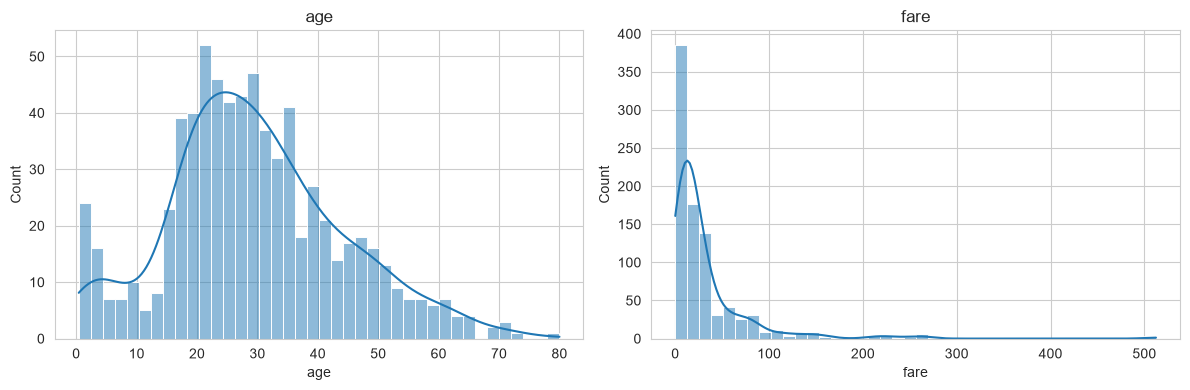

In [22]:
# TODO
for col in['age', 'fare']:
    s=df[col]
    skew_ = stats.skew(s)
    kurt= stats.kurtosis(s)
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt:.2f}")
fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['age'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('age')
sns.histplot(df['fare'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('fare')
plt.tight_layout(); plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [23]:
# TODO
pclass_survived_max=df.groupby('pclass')['survived'].mean().max()
pclass_survived_idmax=df.groupby('pclass')['survived'].mean().idxmax()    
print("Hạng vé có tỷ lệ sống sót cao nhất: ", pclass_survived_idmax)

pclass_survived_min=df.groupby('pclass')['survived'].mean().min()
print(f"Mức chênh lệch: {pclass_survived_max-pclass_survived_min:.2f}")

Hạng vé có tỷ lệ sống sót cao nhất:  1
Mức chênh lệch: 0.39


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [24]:
# TODO
pclass_survived=df.groupby('pclass')['survived'].mean()
sex_survived=df.groupby('sex')['survived'].mean()
print(df.groupby('sex')['survived'].mean())
print(df.groupby('pclass')['survived'].mean())
print(f"Chênh lệch tỷ lệ sống sót của giới tính: {sex_survived.max()-sex_survived.min():.2f}")
print(f"Chênh lệch tỷ lệ sống sót của hạng vé là: {pclass_survived.max()-pclass_survived.min():.2f}")

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64
Chênh lệch tỷ lệ sống sót của giới tính: 0.55
Chênh lệch tỷ lệ sống sót của hạng vé là: 0.39


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

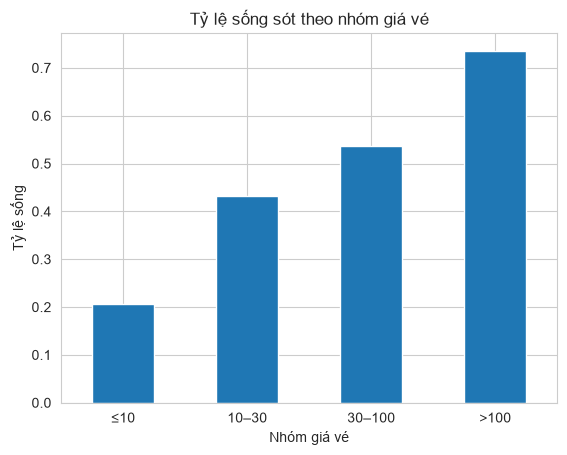

--->Theo biểu đồ cho thấy người có giá vé càng cao thì tỷ lệ sống sót càng cao


In [25]:
df['fare_group'] = pd.cut(
    df['fare'],
    bins=[0, 10, 30, 100, float('inf')],
    labels=['≤10', '10–30', '30–100', '>100']
)

fare_survived = df.groupby('fare_group', observed=True)['survived'].mean()

fare_survived.plot(kind='bar')

plt.title('Tỷ lệ sống sót theo nhóm giá vé')
plt.xlabel('Nhóm giá vé')
plt.ylabel('Tỷ lệ sống')
plt.xticks(rotation=0)
plt.show()
print("--->Theo biểu đồ cho thấy người có giá vé càng cao thì tỷ lệ sống sót càng cao")

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [32]:
# TODO
print(df.groupby('family_size')['survived'].mean())

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64


**Nhận xét:** Tỷ lệ sống sót thay đổi theo quy mô gia đình. Các gia đình có từ 5 người trở lên nhìn chung có tỷ lệ sống sót thấp hơn các gia đình nhỏ hơn.

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [39]:
# TODO
embark_town_sur = df.groupby('embark_town')["survived"].mean()
print(embark_town_sur)
print(f"Tỷ lệ sống sót của người ở cảng Cherbourg là cao nhất với tỷ lệ {embark_town_sur.max():.2f}")

embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64
Tỷ lệ sống sót của người ở cảng Cherbourg là cao nhất với tỷ lệ 0.55


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

- Chất lượng dữ liệu: Bộ dữ liệu có 891 dòng, nhưng cột deck thiếu tới 688 giá trị (gần 77%) và age thiếu 177 giá trị, nên kết quả phân tích liên quan đến boong tàu cần thận trọng.
- Giới tính là yếu tố ảnh hưởng mạnh nhất: Nữ có tỷ lệ sống sót 74%, nam chỉ 19% — chênh lệch 55 điểm phần trăm, lớn hơn cả chênh lệch giữa các hạng vé (39 điểm phần trăm). Điều này phản ánh nguyên tắc ưu tiên "phụ nữ và trẻ em trước".
- Tiền vé/hạng vé cũng có tác động rõ: Hạng 1 có tỷ lệ sống cao nhất; vé càng đắt thì tỷ lệ sống càng cao, cho thấy vị trí khoang và khả năng tiếp cận xuồng cứu sinh liên quan đến điều kiện kinh tế.
- Cảng lên tàu liên quan gián tiếp đến giai cấp: Hành khách lên tàu ở Cherbourg có tỷ lệ sống cao nhất (55%), nhiều khả năng vì tỷ lệ hành khách hạng 1 ở cảng này cao hơn, chứ không phải do bản thân cảng lên tàu.
- Quy mô gia đình có ảnh hưởng dạng chữ U ngược: Người đi một mình (family_size = 1) và gia đình quá đông (≥5 người) có tỷ lệ sống thấp hơn hẳn so với gia đình vừa phải (2–4 người) — có thể do người đi một mình ít được hỗ trợ, còn gia đình đông khó di chuyển/tập hợp kịp lúc.
- Kết luận chung: Khả năng sống sót trên Titanic không ngẫu nhiên mà phản ánh rõ thứ tự ưu tiên cứu hộ và điều kiện kinh tế — xã hội của hành khách, trong đó giới tính là yếu tố quyết định nhất, tiếp theo là hạng vé/giá vé và quy mô gia đình.